## Import Library

In [ ]:
!pip install openpyxl scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats.mstats import winsorize
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# UPLOAD FILE

# 1. Upload Image
from google.colab import files
uploaded = files.upload()

Saving Dataset_kesehatan.xlsx to Dataset_kesehatan.xlsx


In [ ]:
# Load dataset
FILENAME = next(iter(uploaded))
df_raw = pd.read_excel(FILENAME)
df = df_raw.copy()

print(f'Dimensi dataset: {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'Periode: {df["Tahun"].min()} — {df["Tahun"].max()}')
print(f'Provinsi ({df["Provinsi"].nunique()}): {sorted(df["Provinsi"].unique())}')
df.head(10)

Dimensi dataset: 180 baris × 11 kolom
Periode: 2010 — 2024
Provinsi (12): ['Bali', 'DI Yogyakarta', 'DKI Jakarta', 'Jawa Barat', 'Jawa Tengah', 'Jawa Timur', 'Kalimantan Timur', 'Papua', 'Riau', 'Sulawesi Selatan', 'Sumatera Barat', 'Sumatera Utara']


,Tahun,Provinsi,AHH,Kasus_ISPA,Kasus_Diabetes,Kasus_Hipertensi,Tenaga_Medis,Rumah_Sakit,Imunisasi,Angka_Kematian,Penduduk
0,2010,DKI Jakarta,NaN,33465,14756,10840,2693,94,82.8,8.1,35834672
1,2010,Jawa Barat,73.2,21943,10107,28177,13072,73,63.7,14.3,35237299
2,2010,Jawa Tengah,64.3,28529,6833,18620,5909,354,95.9,15.5,28882879
3,2010,DI Yogyakarta,70.4,38870,15426,22071,7026,45,97.0,10.8,5273180
4,2010,Jawa Timur,64.4,37586,19456,9897,7364,131,NaN,5.9,36660235
5,2010,Bali,70.1,37529,9632,16720,14141,343,65.9,9.7,22562887
6,2010,Sumatera Utara,66.1,41929,8323,12835,7398,269,76.3,10.5,31497688
7,2010,Sumatera Barat,66.0,19231,11158,19779,4636,187,65.5,17.2,29440868
8,2010,Riau,71.0,12625,8011,17092,10151,114,89.6,5.2,33697817
9,2010,Kalimantan Timur,72.3,21190,19190,16048,5354,392,82.0,13.6,41942557


# BAGIAN 1 — Audit Data & Asesmen Kualitas

### i. Missing Values

=== RINGKASAN MISSING VALUES ===
           Jumlah Missing  Persentase (%)
AHH                    22           12.22
Imunisasi              20           11.11

Total missing values: 42
Baris terdampak    : 40 dari 180


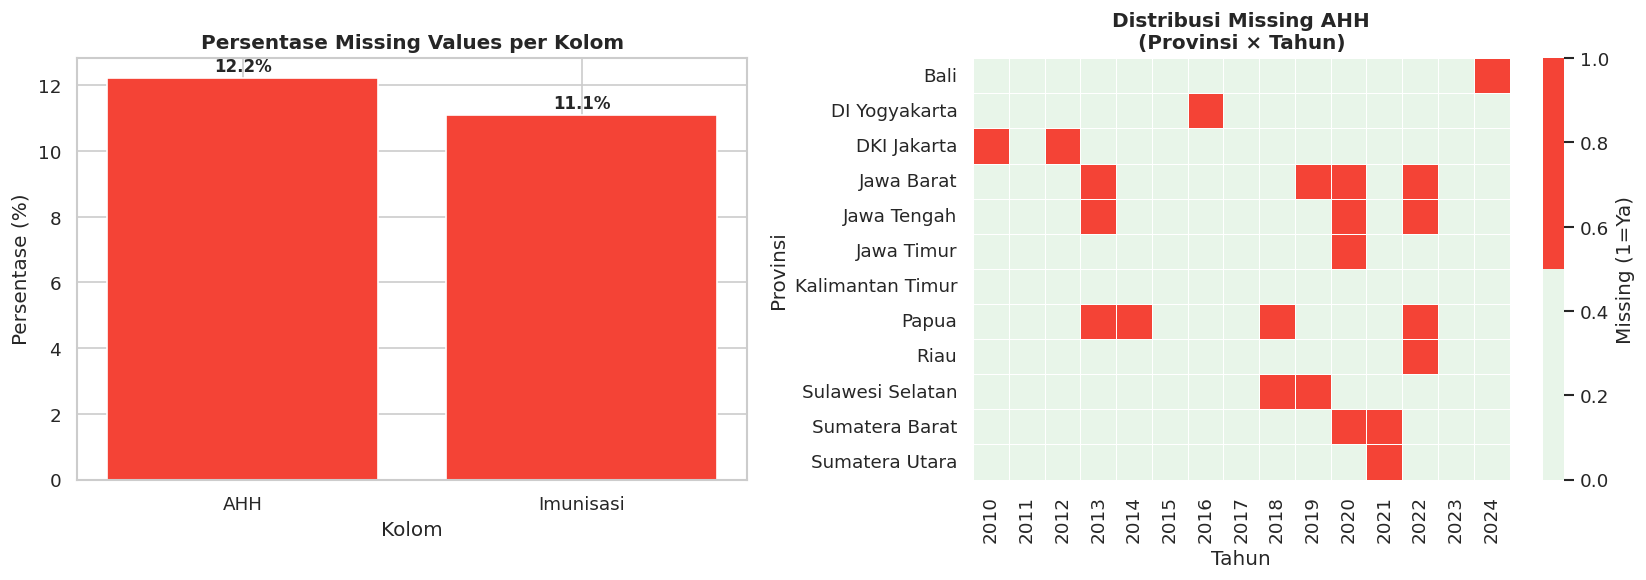


 Plot disimpan: plot_missing_values.png


In [ ]:
# IDENTIFIKASI MISSING VALUES

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct.round(2)
}).query('`Jumlah Missing` > 0')

print('=== RINGKASAN MISSING VALUES ===')
print(missing_df.to_string())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print(f'Baris terdampak    : {df[df.isnull().any(axis=1)].shape[0]} dari {len(df)}')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart missing
cols_missing = missing_df.index
axes[0].bar(cols_missing, missing_df['Persentase (%)'],
            color=[WARNA_BAHAYA if x > 10 else WARNA_PERINGATAN for x in missing_df['Persentase (%)']])
axes[0].set_title('Persentase Missing Values per Kolom', fontweight='bold')
axes[0].set_ylabel('Persentase (%)')
axes[0].set_xlabel('Kolom')
for i, (col, val) in enumerate(zip(cols_missing, missing_df['Persentase (%)'])):
    axes[0].text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Heatmap missing
miss_pivot = df.set_index(['Tahun','Provinsi'])[['AHH','Imunisasi']].isnull().astype(int)
miss_pivot = miss_pivot.reset_index().pivot_table(index='Provinsi', columns='Tahun',
                                                   values='AHH', aggfunc='sum')
sns.heatmap(miss_pivot, ax=axes[1], cmap=['#E8F5E9','#F44336'], linewidths=0.5,
            linecolor='white', cbar_kws={'label': 'Missing (1=Ya)'})
axes[1].set_title('Distribusi Missing AHH\n(Provinsi × Tahun)', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_missing_values.png', bbox_inches='tight')
plt.show()
print('\n Plot disimpan: plot_missing_values.png')

### ii. Outlier

=== RINGKASAN OUTLIER (Metode IQR) ===
           Kolom          Q1          Q3  Batas Bawah  Batas Atas  Jumlah Outlier
             AHH       66.80       72.88        57.69       81.99               0
      Kasus_ISPA    22033.00    40599.75     -5817.12    68449.88               4
  Kasus_Diabetes     8949.00    16751.50     -2754.75    28455.25               0
Kasus_Hipertensi    14542.75    24086.00       227.88    38400.88               0
    Tenaga_Medis     4635.25    10744.50     -4528.62    19908.38               0
     Rumah_Sakit      111.50      309.00      -184.75      605.25               0
       Imunisasi       73.57       89.10        50.29      112.39               0
  Angka_Kematian        7.15       14.60        -4.02       25.78               0
        Penduduk 13949718.75 37565162.75 -21473447.25 72988328.75               0

 Detail Outlier Kasus_ISPA (batas atas = 68,450):
 Tahun         Provinsi  Kasus_ISPA
  2015 Kalimantan Timur      126405
  2017   Sumatera 

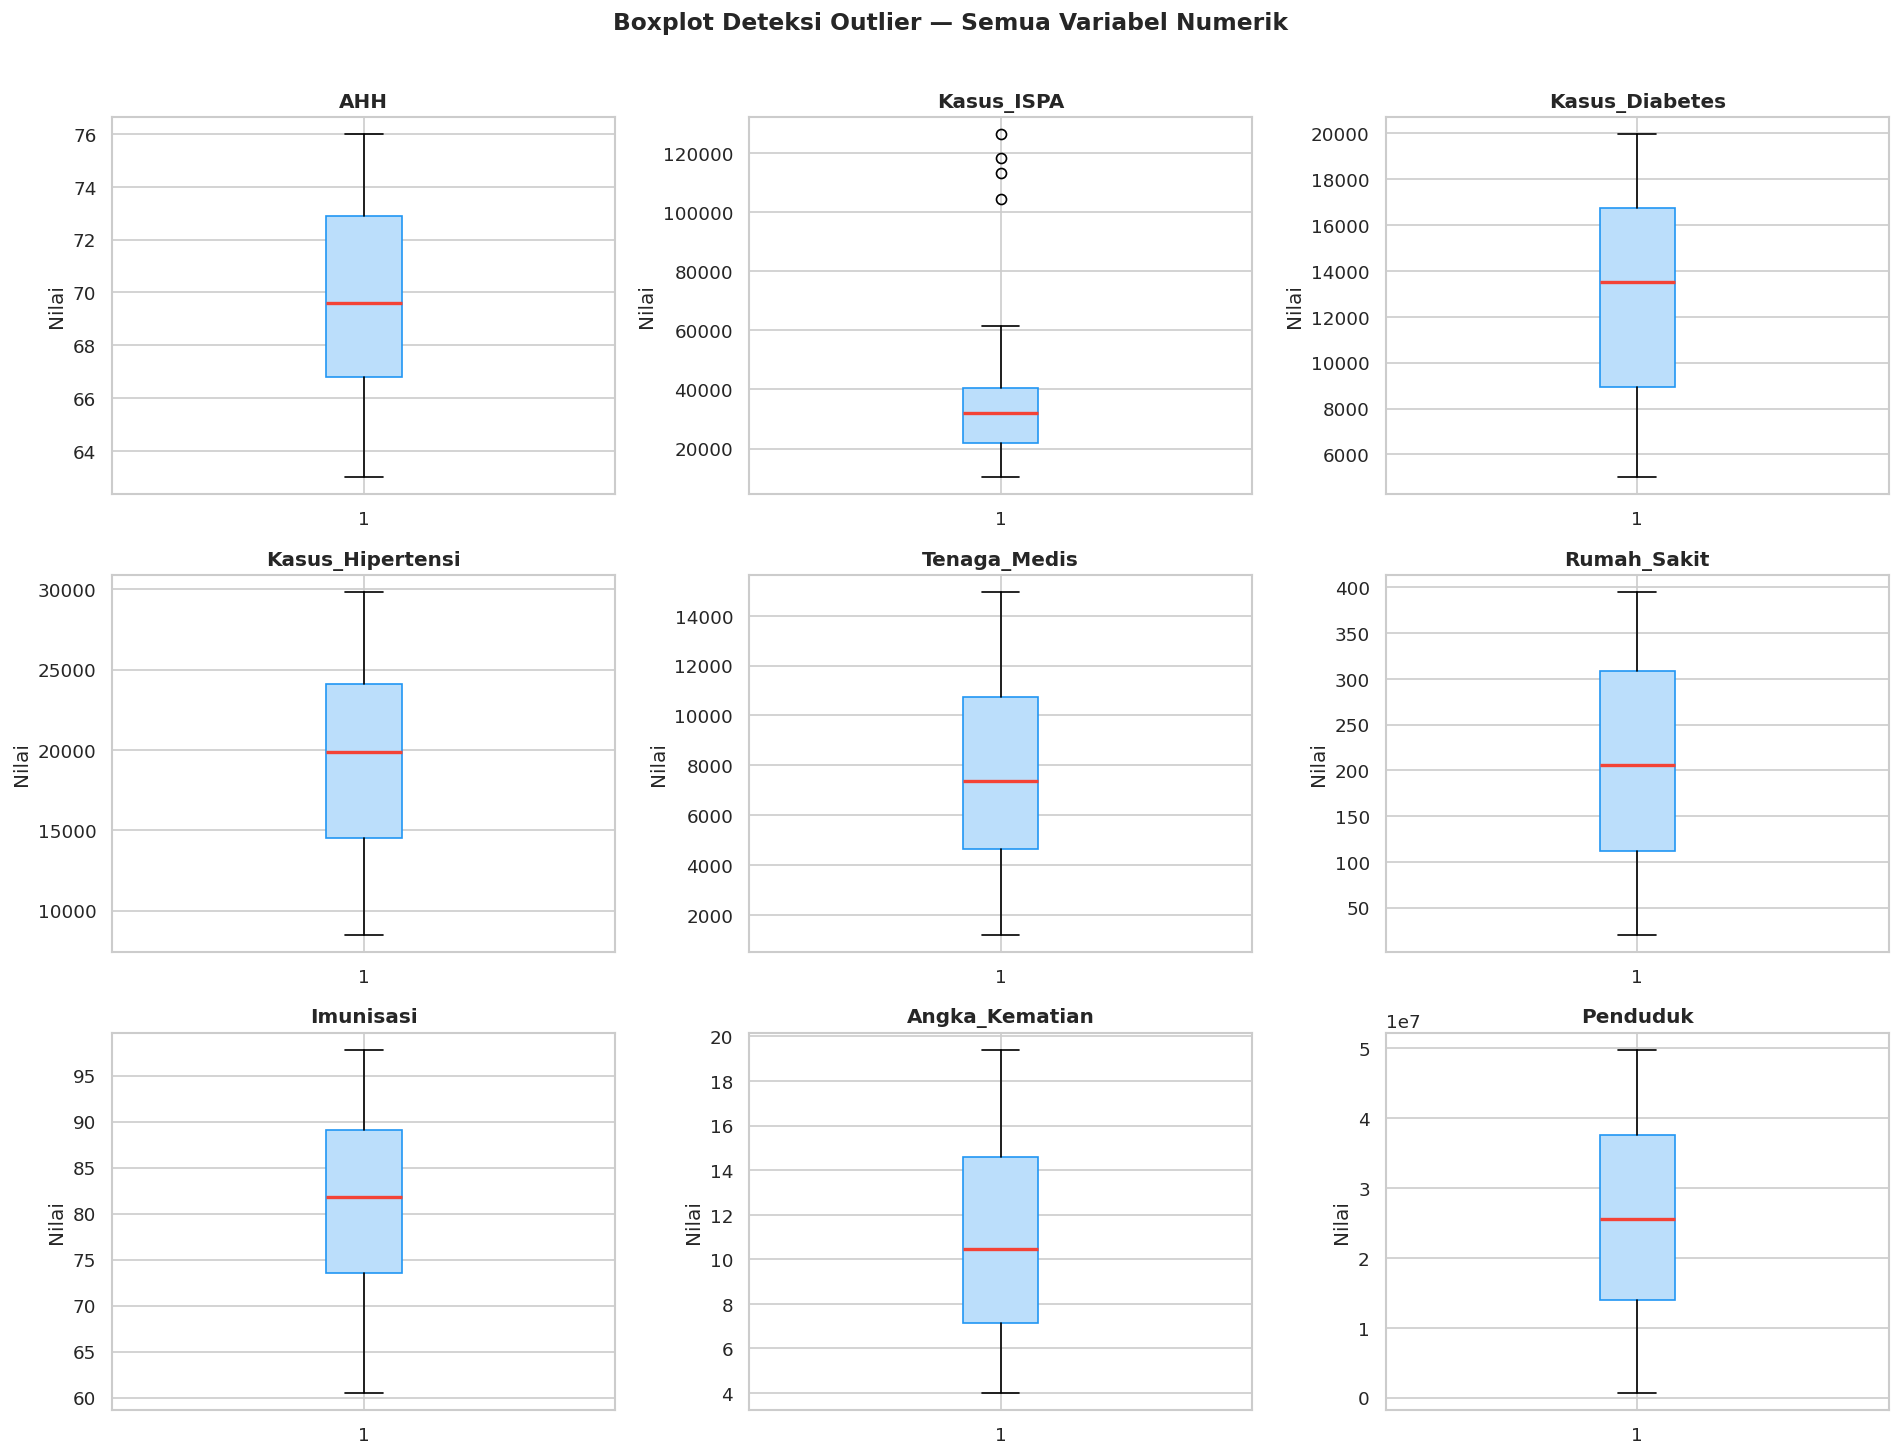

In [ ]:
# -------------------------------------------------------
# IDENTIFIKASI OUTLIER — Metode IQR
# -------------------------------------------------------
numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'Tahun']

outlier_summary = []
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary.append({
        'Kolom': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'Batas Bawah': round(lower,2), 'Batas Atas': round(upper,2),
        'Jumlah Outlier': n_out
    })

out_df = pd.DataFrame(outlier_summary)
print('=== RINGKASAN OUTLIER (Metode IQR) ===')
print(out_df.to_string(index=False))

# Detail outlier Kasus_ISPA
col = 'Kasus_ISPA'
Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
upper = Q3 + 1.5*(Q3-Q1)
print(f'\n Detail Outlier {col} (batas atas = {upper:,.0f}):')
print(df[df[col] > upper][['Tahun','Provinsi',col]].to_string(index=False))

# Boxplot semua kolom numerik
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#BBDEFB', color=WARNA_UTAMA),
                    medianprops=dict(color=WARNA_BAHAYA, linewidth=2),
                    flierprops=dict(marker='o', color=WARNA_BAHAYA, markersize=6))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Nilai')

plt.suptitle('Boxplot Deteksi Outlier — Semua Variabel Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_outlier_boxplot.png', bbox_inches='tight')
plt.show()

### iii. Inkonsistensi Data

=== CEK INKONSISTENSI DATA ===

1. Baris duplikat      : 0 baris 
2. AHH di luar 0–100   : 0 baris
3. Imunisasi > 100%    : 0 baris 
4. Angka_Kematian < 0  : 0 baris
5. Rumah_Sakit < 0     : 0 baris
6. Kelengkapan data    : 180/180 kombinasi Tahun × Provinsi 

=== JUMLAH DATA PER PROVINSI ===
Provinsi
DKI Jakarta         15
Jawa Barat          15
Jawa Tengah         15
DI Yogyakarta       15
Jawa Timur          15
Bali                15
Sumatera Utara      15
Sumatera Barat      15
Riau                15
Kalimantan Timur    15
Sulawesi Selatan    15
Papua               15


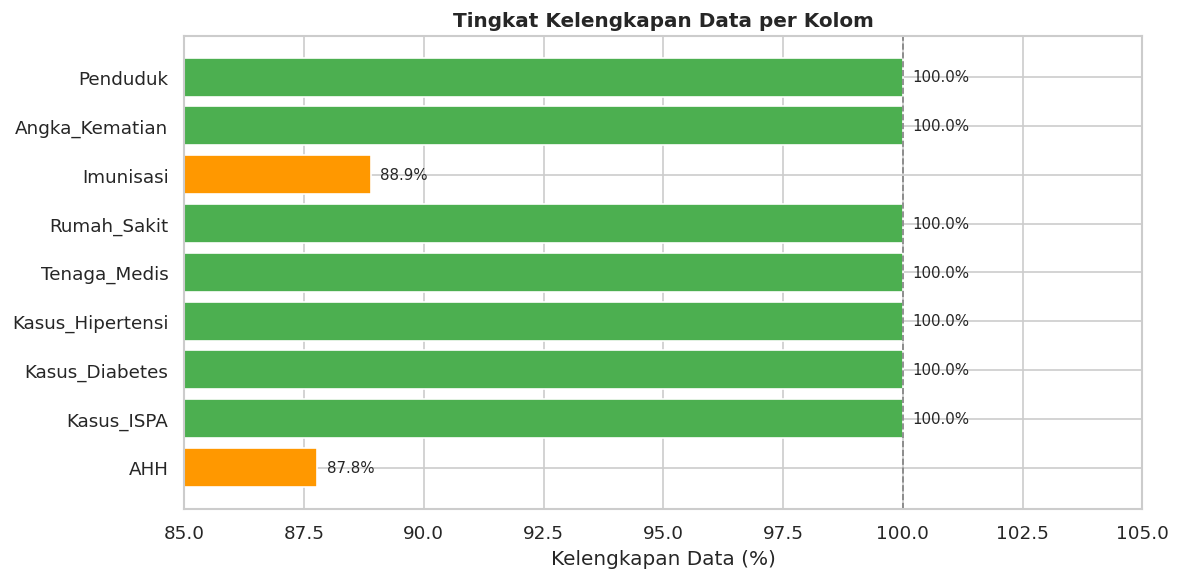

In [ ]:
# IDENTIFIKASI INKONSISTENSI DATA

print('=== CEK INKONSISTENSI DATA ===\n')

# 1. Duplikasi
dup = df.duplicated().sum()
print(f'1. Baris duplikat      : {dup} baris ')

# 2. Range
ahh_invalid = df[(df['AHH'] < 0) | (df['AHH'] > 100)].shape[0]
imun_invalid = df[(df['Imunisasi'] < 0) | (df['Imunisasi'] > 100)].shape[0]
ak_invalid = df[df['Angka_Kematian'] < 0].shape[0]
rs_invalid = df[df['Rumah_Sakit'] < 0].shape[0]
print(f'2. AHH di luar 0–100   : {ahh_invalid} baris')
print(f'3. Imunisasi > 100%    : {imun_invalid} baris ')
print(f'4. Angka_Kematian < 0  : {ak_invalid} baris')
print(f'5. Rumah_Sakit < 0     : {rs_invalid} baris')

# 3. Kelengkapan kombinasi Tahun × Provinsi
expected_rows = df['Tahun'].nunique() * df['Provinsi'].nunique()
actual_rows   = len(df)
print(f'6. Kelengkapan data    : {actual_rows}/{expected_rows} kombinasi Tahun × Provinsi ')

# 4. Distribusi per provinsi
print('\n=== JUMLAH DATA PER PROVINSI ===')
print(df['Provinsi'].value_counts().to_string())

# Visualisasi completeness
completeness = (1 - df[numeric_cols].isnull().mean()) * 100
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(completeness.index, completeness.values,
               color=[WARNA_SUKSES if v == 100 else WARNA_PERINGATAN for v in completeness.values])
ax.axvline(100, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(85, 105)
ax.set_xlabel('Kelengkapan Data (%)')
ax.set_title('Tingkat Kelengkapan Data per Kolom', fontweight='bold')
for bar, val in zip(bars, completeness.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_Kelengkapan_Data.png', bbox_inches='tight')
plt.show()

# BAGIAN 2 Data Cleaning


=== HASIL IMPUTASI ===
Missing setelah imputasi: AHH=0, Imunisasi=0

--- AHH ---
  Mean  : 69.700 → 69.668
  Median: 69.600 → 69.200
  Std   : 3.635 → 3.428
--- Imunisasi ---
  Mean  : 80.992 → 81.123
  Median: 81.750 → 82.100
  Std   : 10.172 → 9.629


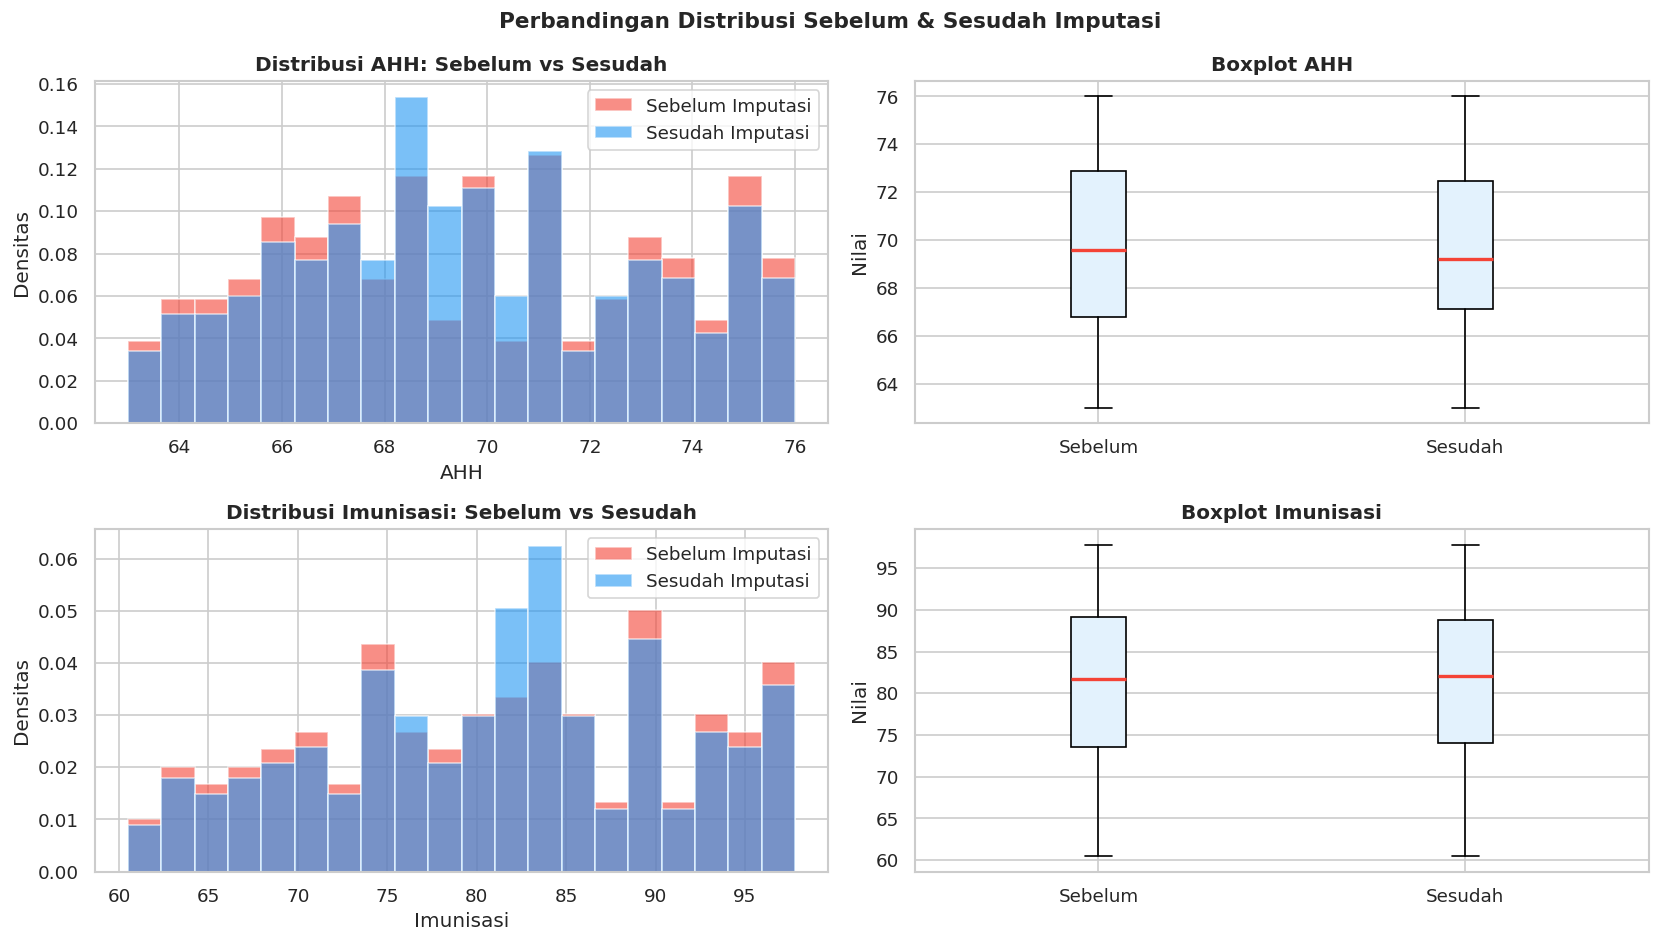

In [ ]:
# Median per Provinsi

df_clean = df.copy()

# Simpan statistik sebelum imputasi
ahh_before   = df_clean['AHH'].describe()
imun_before  = df_clean['Imunisasi'].describe()

# Imputasi AHH dengan median per provinsi
df_clean['AHH'] = df_clean.groupby('Provinsi')['AHH'].transform(
    lambda x: x.fillna(x.median())
)

# Imputasi Imunisasi dengan median per provinsi
df_clean['Imunisasi'] = df_clean.groupby('Provinsi')['Imunisasi'].transform(
    lambda x: x.fillna(x.median())
)

# jika seluruh provinsi kosong, gunakan median global
df_clean['AHH'].fillna(df_clean['AHH'].median(), inplace=True)
df_clean['Imunisasi'].fillna(df_clean['Imunisasi'].median(), inplace=True)

# Verifikasi
remaining_miss = df_clean[['AHH','Imunisasi']].isnull().sum()
print('=== HASIL IMPUTASI ===')
print(f'Missing setelah imputasi: AHH={remaining_miss["AHH"]}, Imunisasi={remaining_miss["Imunisasi"]}')
print()

# Perbandingan distribusi sebelum vs sesudah
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(['AHH', 'Imunisasi']):
    # before vs after
    axes[i][0].hist(df[col].dropna(), bins=20, alpha=0.6, color=WARNA_BAHAYA,
                    density=True, label='Sebelum Imputasi')
    axes[i][0].hist(df_clean[col], bins=20, alpha=0.6, color=WARNA_UTAMA,
                    density=True, label='Sesudah Imputasi')
    axes[i][0].set_title(f'Distribusi {col}: Sebelum vs Sesudah', fontweight='bold')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Densitas')
    axes[i][0].legend()

    # Boxplot
    data_bp = [df[col].dropna().values, df_clean[col].values]
    bp = axes[i][1].boxplot(data_bp, patch_artist=True, labels=['Sebelum', 'Sesudah'],
                             boxprops=dict(facecolor='#E3F2FD'),
                             medianprops=dict(color=WARNA_BAHAYA, linewidth=2))
    axes[i][1].set_title(f'Boxplot {col}', fontweight='bold')
    axes[i][1].set_ylabel('Nilai')

    # Statistik
    stats_after = df_clean[col].describe()
    before_stat = df[col].describe()
    print(f'--- {col} ---')
    print(f'  Mean  : {before_stat["mean"]:.3f} → {stats_after["mean"]:.3f}')
    print(f'  Median: {before_stat["50%"]:.3f} → {stats_after["50%"]:.3f}')
    print(f'  Std   : {before_stat["std"]:.3f} → {stats_after["std"]:.3f}')

plt.suptitle('Perbandingan Distribusi Sebelum & Sesudah Imputasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_imputasi.png', bbox_inches='tight')
plt.show()

## Penanganan Outlier — Winsorize

=== WINSORIZING: Kasus_ISPA ===
Batas bawah (P5)  : 12,895
Batas atas  (P95) : 48,351
Sebelum — Mean: 33,041.94 | Std: 16,613.30
Sesudah — Mean: 31,511.85 | Std: 10,884.34
Perubahan Mean: 1,530.09 (4.63%)


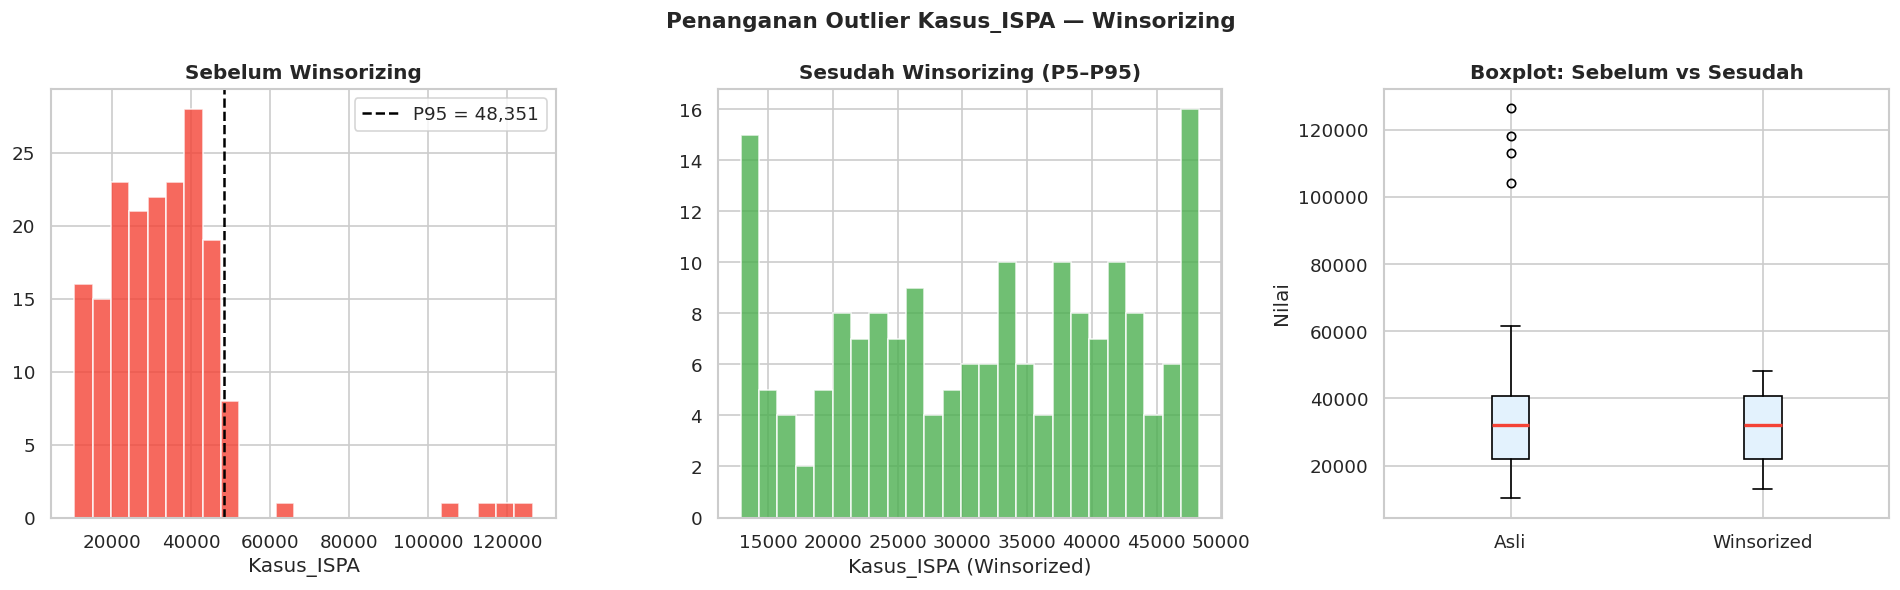

In [ ]:


col = 'Kasus_ISPA'

# Hitung batas
p5  = df_clean[col].quantile(0.05)
p95 = df_clean[col].quantile(0.95)
before_mean = df_clean[col].mean()
before_std  = df_clean[col].std()

print(f'=== WINSORIZING: {col} ===')
print(f'Batas bawah (P5)  : {p5:,.0f}')
print(f'Batas atas  (P95) : {p95:,.0f}')
print(f'Sebelum — Mean: {before_mean:,.2f} | Std: {before_std:,.2f}')

# Terapkan winsorizing
winsorized = winsorize(df_clean[col].values, limits=[0.05, 0.05])
df_clean[col + '_Win'] = winsorized

after_mean = df_clean[col + '_Win'].mean()
after_std  = df_clean[col + '_Win'].std()
print(f'Sesudah — Mean: {after_mean:,.2f} | Std: {after_std:,.2f}')
print(f'Perubahan Mean: {abs(before_mean - after_mean):,.2f} ({abs(before_mean - after_mean)/before_mean*100:.2f}%)')

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram sebelum
axes[0].hist(df_clean[col], bins=25, color=WARNA_BAHAYA, alpha=0.8, edgecolor='white')
axes[0].axvline(p95, color='black', linestyle='--', linewidth=1.5, label=f'P95 = {p95:,.0f}')
axes[0].set_title('Sebelum Winsorizing', fontweight='bold')
axes[0].set_xlabel('Kasus_ISPA')
axes[0].legend()

# Histogram sesudah
axes[1].hist(df_clean[col + '_Win'], bins=25, color=WARNA_SUKSES, alpha=0.8, edgecolor='white')
axes[1].set_title('Sesudah Winsorizing (P5–P95)', fontweight='bold')
axes[1].set_xlabel('Kasus_ISPA (Winsorized)')

# Boxplot perbandingan
bp = axes[2].boxplot([df_clean[col], df_clean[col + '_Win']],
                      patch_artist=True,
                      labels=['Asli', 'Winsorized'],
                      boxprops=dict(facecolor='#E3F2FD'),
                      medianprops=dict(color=WARNA_BAHAYA, linewidth=2),
                      flierprops=dict(marker='o', color=WARNA_BAHAYA, markersize=5))
axes[2].set_title('Boxplot: Sebelum vs Sesudah', fontweight='bold')
axes[2].set_ylabel('Nilai')

plt.suptitle(f'Penanganan Outlier {col} — Winsorizing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_winsorizing.png', bbox_inches='tight')
plt.show()

# Ganti kolom asli dengan yang sudah diwinsorize
df_clean[col] = df_clean[col + '_Win']
df_clean.drop(columns=[col + '_Win'], inplace=True)

## Normalisasi — Min-Max Scaling

=== HASIL NORMALISASI MIN-MAX ===
           Kolom  Min Asli   Max Asli     Range Baru
             AHH      63.0       76.0 [0.000, 1.000]
      Kasus_ISPA   12901.0    48298.0 [0.000, 1.000]
  Kasus_Diabetes    5007.0    19979.0 [0.000, 1.000]
Kasus_Hipertensi    8475.0    29834.0 [0.000, 1.000]
    Tenaga_Medis    1196.0    14956.0 [0.000, 1.000]
     Rumah_Sakit      20.0      395.0 [0.000, 1.000]
       Imunisasi      60.5       97.8 [0.000, 1.000]
  Angka_Kematian       4.0       19.4 [0.000, 1.000]
        Penduduk  647364.0 49802834.0 [0.000, 1.000]


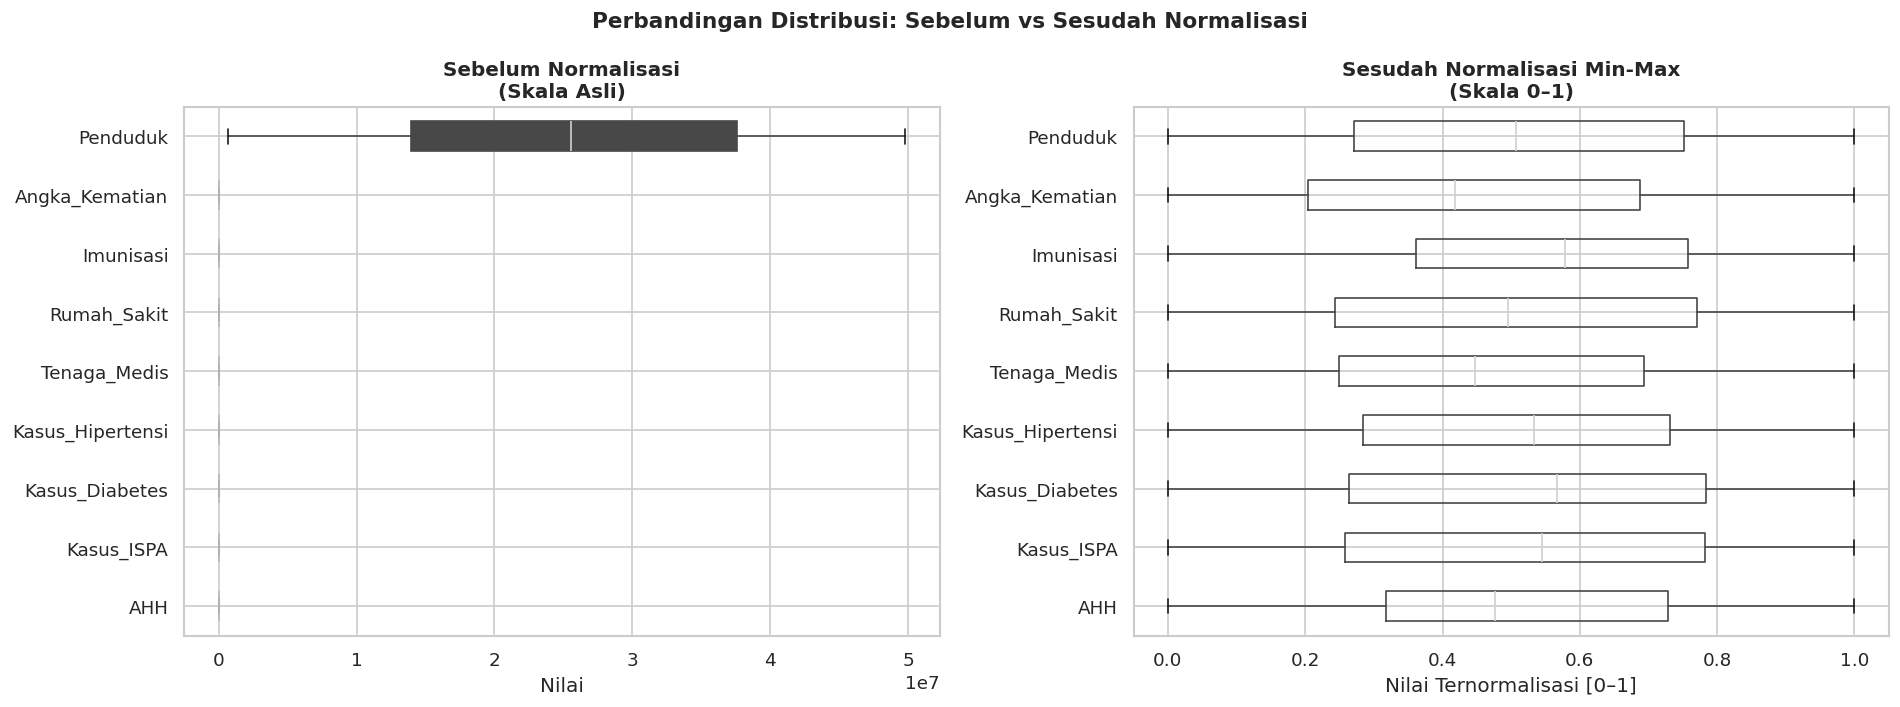

In [ ]:


cols_to_normalize = ['AHH', 'Kasus_ISPA', 'Kasus_Diabetes', 'Kasus_Hipertensi',
                     'Tenaga_Medis', 'Rumah_Sakit', 'Imunisasi', 'Angka_Kematian', 'Penduduk']

df_normalized = df_clean.copy()

normalization_info = []
for col in cols_to_normalize:
    min_val = df_normalized[col].min()
    max_val = df_normalized[col].max()
    df_normalized[col + '_Norm'] = (df_normalized[col] - min_val) / (max_val - min_val)
    normalization_info.append({'Kolom': col, 'Min Asli': round(min_val,2),
                                'Max Asli': round(max_val,2),
                                'Range Baru': '[0.000, 1.000]'})

norm_df = pd.DataFrame(normalization_info)
print('=== HASIL NORMALISASI MIN-MAX ===')
print(norm_df.to_string(index=False))

# Visualisasi: sebelum vs sesudah normalisasi
norm_cols = [c + '_Norm' for c in cols_to_normalize]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sebelum normalisasi
df_clean[cols_to_normalize].boxplot(ax=axes[0], vert=False,
                                     patch_artist=True)
axes[0].set_title('Sebelum Normalisasi\n(Skala Asli)', fontweight='bold')
axes[0].set_xlabel('Nilai')

# Sesudah normalisasi
df_normalized[norm_cols].rename(columns=lambda c: c.replace('_Norm',''))\
    .boxplot(ax=axes[1], vert=False)
axes[1].set_title('Sesudah Normalisasi Min-Max\n(Skala 0–1)', fontweight='bold')
axes[1].set_xlabel('Nilai Ternormalisasi [0–1]')

plt.suptitle('Perbandingan Distribusi: Sebelum vs Sesudah Normalisasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_normalisasi.png', bbox_inches='tight')
plt.show()

# Ekspor Dataset


 Dataset Asli   : 180 baris × 11 kolom
Dataset Bersih : 180 baris × 11 kolom
Tidak ada baris dihapus 

--- Status Missing Values ---
Total missing values tersisa: 0 

--- Statistik Deskriptif Dataset Bersih ---
          AHH  Kasus_ISPA  Imunisasi  Angka_Kematian
count  180.00      180.00     180.00          180.00
mean    69.67    31511.85      81.12           10.80
std      3.43    10884.34       9.63            4.24
min     63.00    12901.00      60.50            4.00
25%     67.12    22033.00      74.00            7.15
50%     69.20    32203.50      82.10           10.45
75%     72.46    40599.75      88.75           14.60
max     76.00    48298.00      97.80           19.40


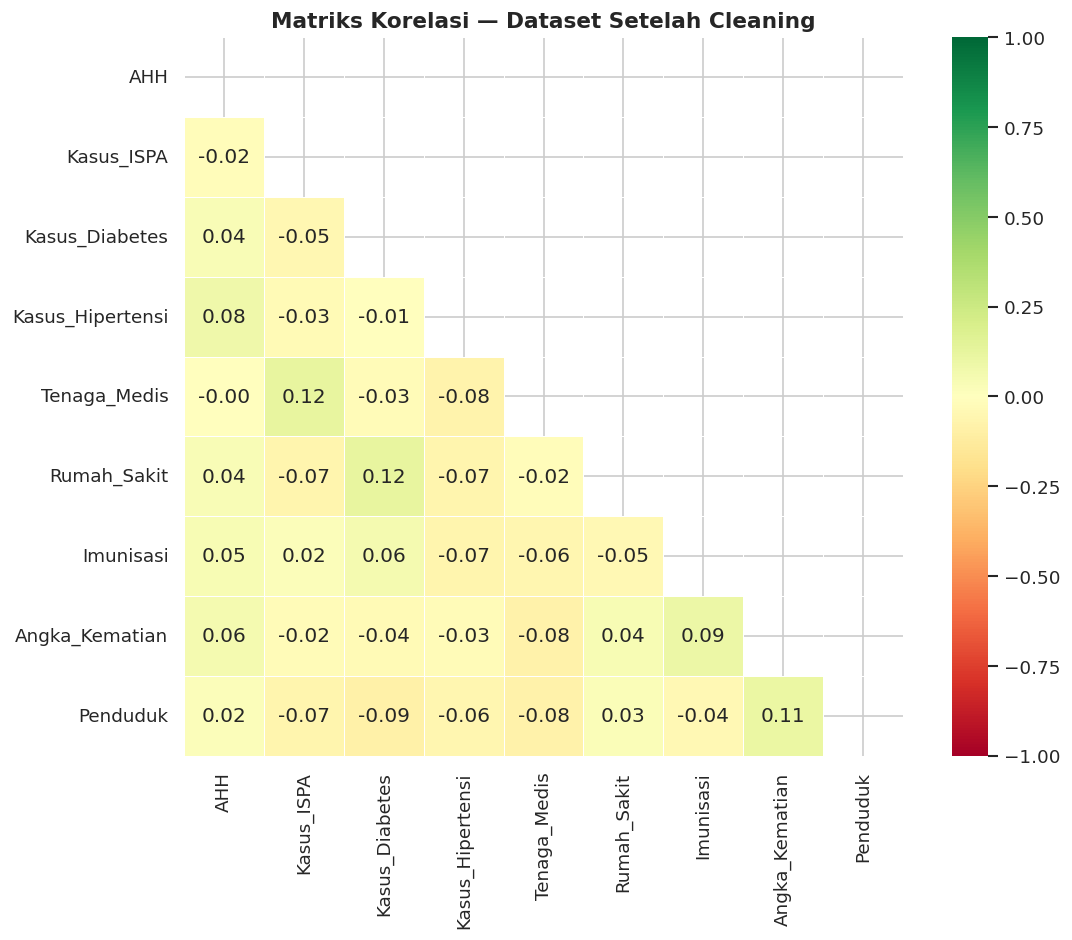

In [ ]:
# VERIFIKASI KUALITAS DATA AKHIR

print(f'\n Dataset Asli   : {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'Dataset Bersih : {df_clean.shape[0]} baris × {df_clean.shape[1]} kolom')
print(f'Tidak ada baris dihapus ')

print('\n--- Status Missing Values ---')
remaining = df_clean.isnull().sum().sum()
print(f'Total missing values tersisa: {remaining} ')

print('\n--- Statistik Deskriptif Dataset Bersih ---')
print(df_clean[['AHH','Kasus_ISPA','Imunisasi','Angka_Kematian']].describe().round(2).to_string())

# Korelasi untuk pemahaman awal
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_clean[cols_to_normalize].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', ax=ax,
            cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
ax.set_title('Matriks Korelasi — Dataset Setelah Cleaning', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_korelasi.png', bbox_inches='tight')
plt.show()

In [ ]:
# EKSPOR FILE

# File 1: Dataset bersih
output_cleaned = 'dataset_kesehatan_CLEANED.xlsx'
df_clean.to_excel(output_cleaned, index=False)


files.download(output_cleaned)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>